In [1]:
from configs import *
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from scipy.linalg import solve_discrete_are
import imageio


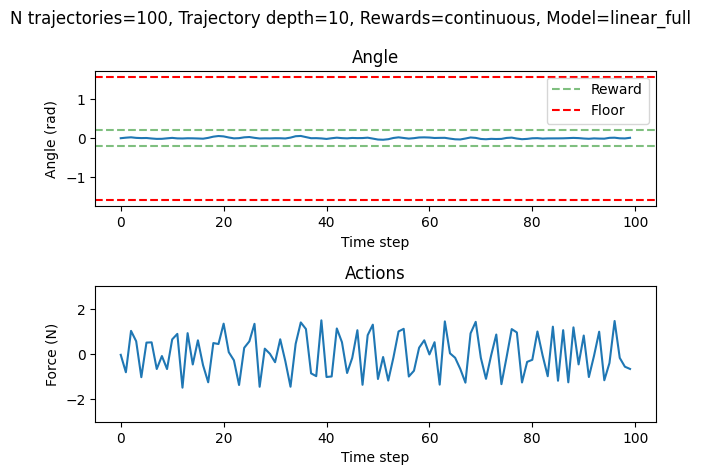

In [2]:
def simulate(bird, n_episodes, time_steps):
    """ Simulate bird, possible episodic SARSA. """

    # Initialize trajectory tracking [episode, time_step, SAR]
    hist = np.zeros((n_episodes, time_steps, 3), dtype=int)

    # Episodic loop
    for epi in range(n_episodes):
        episode_seed = 54 + epi
        np.random.seed(episode_seed)
        # Create the environment
        env = gym.make("InvertedPendulum-v5", render_mode="rgb_array", reset_noise_scale=0.001) 
        env.reset(seed=episode_seed)
        writer = imageio.get_writer("output.gif", fps=30)

        angles   = np.zeros((time_steps))
        actions  = np.zeros((time_steps))
        rewards  = np.zeros((time_steps))

        for t in range(time_steps):
            #print(f"States: {env.unwrapped.data.qpos}, {env.unwrapped.data.qvel}")
            action = bird.mujoco_policy(env)
            actions[t] = action

            obs, reward, done, truncated, info = env.step(np.array([action]))

            angles[t] = obs[1]
            rewards[t] = reward

            if epi == n_episodes - 1:
                frame = env.render()  # Returns a NumPy RGB array (H, W, 3)
                frame = np.asarray(frame).astype(np.uint8)
                writer.append_data(frame)

            # Learning
            # if train: bird.update(state, action, reward, next_state, next_action)

        # Release the VideoWriter object and close the environment
        writer.close()
        env.close()

    return angles, actions, rewards


# Simulate the bird
planning_width = 100 # how many trajectories to simulate
n_planning = 10 # how deep the rolout of each trajectory is
reward_type='continuous' # rewards can be 'discrete' or 'continuous'
model_type='linear_full' # model can be 'mujoco' or 'linear_full' or 'linear_reduced_<int>' where <int> is the rank of the model

bird = MPCShittyBird(n_actions = 10, planning_width=planning_width, n_planning=n_planning, reward_type=reward_type, model_type=model_type) 

angle, actions, rewards = simulate(bird, n_episodes=1, time_steps=100)

plt.figure()
plt.suptitle(f'N trajectories={planning_width}, Trajectory depth={n_planning}, Rewards={reward_type}, Model={model_type}', fontsize=12)

# Plot the angle
plt.subplot(2, 1, 1)
plt.plot(angle)
plt.title('Angle')
plt.xlabel('Time step')
plt.ylabel('Angle (rad)')
plt.axhline(y=-0.2, color='g', linestyle='--', alpha=0.5, label='Reward')
plt.axhline(y=0.2, color='g', linestyle='--', alpha=0.5)
plt.axhline(y=-1.573, color='r', linestyle='--', label='Floor')
plt.axhline(y=1.573, color='r', linestyle='--')
plt.legend()

# Plot the actions
plt.subplot(2, 1, 2)
plt.plot(actions)
plt.title('Actions')
plt.xlabel('Time step')
plt.ylabel('Force (N)')
plt.ylim(-3, 3)

plt.tight_layout()
